Training Mesh Grid model...
Training Monte Carlo model...
Training Latin Hypercube model...

COMPARISON: Mesh vs Monte Carlo vs Latin Hypercube
Method             |  Rel.Error (%) |     MaxAbs |   PredTime (s) |      beta0
--------------------------------------------------------------------------------
Mesh Grid          |          0.732 |     0.0801 |   3.332270e-04 |     0.1788
Monte Carlo        |          7.526 |     0.2646 |   2.150021e-04 |     0.0796
Latin Hypercube    |          1.646 |     0.0975 |   2.848188e-04 |     0.0817


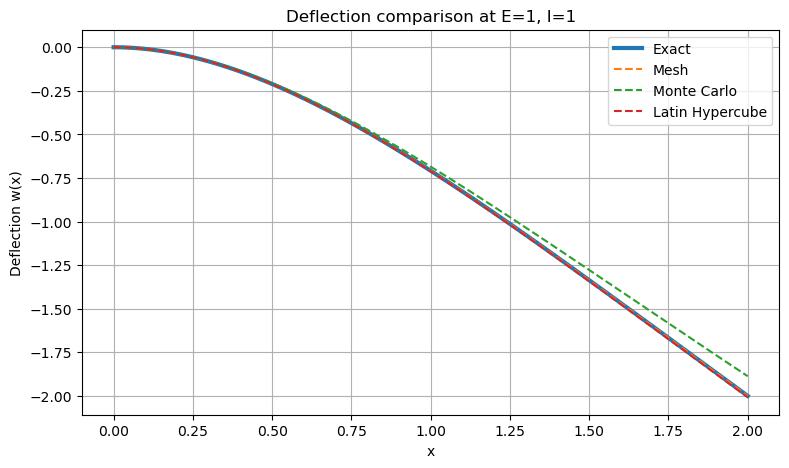

In [4]:
# =============================================================================
# FULL PIELM COMPARISON NOTEBOOK
# Mesh Grid vs Monte Carlo vs Latin Hypercube (LHS)
# =============================================================================

import torch
import torch.autograd as autograd
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.stats import qmc

torch.set_default_dtype(torch.float32)

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION (PHYSICAL w)
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    xbar = xei[:, 0:1] / L  # [0,1]
    Ehat = 2*(xei[:, 1:2] - E_range[0])/(E_range[1]-E_range[0]) - 1
    Ihat = 2*(xei[:, 2:3] - I_range[0])/(I_range[1]-I_range[0]) - 1
    return torch.cat([xbar, Ehat, Ihat], dim=1)

# =============================================================================
# DERIVATIVES wrt x (xei[:,0])
# =============================================================================
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:, 0:1]
    return cur

# =============================================================================
# BUILD PHYSICAL PREDICTOR FROM ELM PARAMETERS
# =============================================================================
def build_predictor(W, b, beta, beta0, gauss_scale):
    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # physical w = (Q L^4/(E I)) * wbar
    # wbar = xbar^2*(H beta + beta0)
    def predict(xei):
        x = xei[:, 0:1]
        E = xei[:, 1:2]
        I = xei[:, 2:3]

        xbar = x / L
        H = activation(normalize(xei) @ W + b)
        wbar = (xbar**2) * (H @ beta + beta0)
        w_phys = (Q * L**4 / (E * I)) * wbar
        return w_phys

    return predict

# =============================================================================
# CORE TRAIN FUNCTION (KKT) — SAME FOR ALL SAMPLERS
# =============================================================================
def train_pielm(xei, xei_bc, hidden_size, lambda_reg, gauss_scale):
    # Random Gaussian ELM params
    W = torch.randn(3, hidden_size) * 0.1
    b = torch.randn(hidden_size) * 0.1

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # ----------------------------
    # PDE matrix for dimensionless wbar:
    # enforce: L^4 * d^4(wbar)/dx^4 = 1
    # wbar = xbar^2*(H beta + beta0)
    # ----------------------------
    xbar = xei[:, 0:1] / L
    H = activation(normalize(xei) @ W + b)
    Phi = (xbar**2) * H
    Phi_aug = torch.hstack([Phi, xbar**2])  # beta0 term

    Acols = []
    for j in range(hidden_size + 1):
        basis_j = Phi_aug[:, j:j+1]
        w4 = derivative(basis_j, xei, 4)
        Acols.append((L**4) * w4)

    A_pde = torch.hstack(Acols)
    b_pde = torch.ones(A_pde.shape[0], 1)

    # ----------------------------
    # Boundary conditions at x=L:
    # wbar''(L) = 0, wbar'''(L) = 0
    # ----------------------------
    xbarL = xei_bc[:, 0:1] / L
    HL = activation(normalize(xei_bc) @ W + b)
    PhiL = (xbarL**2) * HL
    PhiL_aug = torch.hstack([PhiL, xbarL**2])

    BC2_cols, BC3_cols = [], []
    for j in range(hidden_size + 1):
        basisLj = PhiL_aug[:, j:j+1]
        BC2_cols.append(derivative(basisLj, xei_bc, 2))
        BC3_cols.append(derivative(basisLj, xei_bc, 3))

    C = torch.vstack([torch.hstack(BC2_cols), torch.hstack(BC3_cols)])
    d = torch.zeros(C.shape[0], 1)

    # ----------------------------
    # KKT system (ridge on beta_aug)
    # ----------------------------
    A_T = A_pde.T
    C_T = C.T

    KKT = torch.vstack([
        torch.hstack([A_T @ A_pde + lambda_reg * torch.eye(hidden_size + 1), C_T]),
        torch.hstack([C, torch.zeros((C.shape[0], C.shape[0]))])
    ])

    rhs = torch.vstack([A_T @ b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)

    beta_aug = sol[:hidden_size + 1]
    beta = beta_aug[:hidden_size]
    beta0 = beta_aug[hidden_size].item()

    predict = build_predictor(W, b, beta, beta0, gauss_scale)
    return predict, beta0

# =============================================================================
# SAMPLERS
# =============================================================================
def mesh_sampler(nx=25, ne=10, ni=10):
    x = torch.linspace(0, L, nx)
    E = torch.linspace(E_range[0], E_range[1], ne)
    I = torch.linspace(I_range[0], I_range[1], ni)
    X, Eg, Ig = torch.meshgrid(x, E, I, indexing='ij')
    return torch.cat([X.reshape(-1,1), Eg.reshape(-1,1), Ig.reshape(-1,1)], dim=1)

def mc_sampler(n=4000):
    x = torch.rand(n,1) * L
    E = E_range[0] + torch.rand(n,1) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.rand(n,1) * (I_range[1]-I_range[0])
    return torch.cat([x,E,I], dim=1)

def lhs_sampler(n=12000, seed=0):
    # IMPORTANT FIX: force float32
    sampler = qmc.LatinHypercube(d=3, seed=seed)
    lhs = sampler.random(n)

    x = torch.tensor(lhs[:,0:1], dtype=torch.float32) * L
    E = E_range[0] + torch.tensor(lhs[:,1:2], dtype=torch.float32) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.tensor(lhs[:,2:3], dtype=torch.float32) * (I_range[1]-I_range[0])

    return torch.cat([x,E,I], dim=1)

# =============================================================================
# VALIDATION (same for all)
# =============================================================================
def validate(predict, n_test=10000):
    xei = mc_sampler(n_test)
    w_pred = predict(xei)
    w_exact = analytical_solution(xei[:,0:1], xei[:,1:2], xei[:,2:3])
    rel = torch.norm(w_pred - w_exact) / torch.norm(w_exact)
    max_abs = torch.max(torch.abs(w_pred - w_exact)).item()
    return rel.item(), max_abs

# =============================================================================
# PREDICTION TIME (inference only)
# =============================================================================
def pred_time(predict, n_points=5000, n_repeat=20):
    xei = mc_sampler(n_points)
    predict(xei)  # warm-up

    t0 = time.perf_counter()
    for _ in range(n_repeat):
        predict(xei)
    t1 = time.perf_counter()
    return (t1 - t0) / n_repeat

# =============================================================================
# TRAIN THREE MODELS
# =============================================================================
print("Training Mesh Grid model...")
xei_mesh = mesh_sampler(nx=25, ne=10, ni=10).requires_grad_(True)

print("Training Monte Carlo model...")
xei_mc = mc_sampler(4000).requires_grad_(True)

print("Training Latin Hypercube model...")
xei_lhs = lhs_sampler(12000, seed=0).requires_grad_(True)

# Boundary condition points (same for all)
xei_bc = mc_sampler(300)
xei_bc[:,0:1] = L  # enforce x=L
xei_bc = xei_bc.requires_grad_(True)

# Train
mesh_predict, mesh_beta0 = train_pielm(xei_mesh, xei_bc, hidden_size=50, lambda_reg=1.0, gauss_scale=0.5)
mc_predict, mc_beta0     = train_pielm(xei_mc,   xei_bc, hidden_size=50, lambda_reg=1.0, gauss_scale=0.5)
lhs_predict, lhs_beta0   = train_pielm(xei_lhs,  xei_bc, hidden_size=80, lambda_reg=2.0, gauss_scale=0.3)

# =============================================================================
# COMPARE
# =============================================================================
mesh_err, mesh_max = validate(mesh_predict)
mc_err, mc_max     = validate(mc_predict)
lhs_err, lhs_max   = validate(lhs_predict)

mesh_t = pred_time(mesh_predict)
mc_t   = pred_time(mc_predict)
lhs_t  = pred_time(lhs_predict)

print("\n" + "="*80)
print("COMPARISON: Mesh vs Monte Carlo vs Latin Hypercube")
print("="*80)
print(f"{'Method':<18} | {'Rel.Error (%)':>14} | {'MaxAbs':>10} | {'PredTime (s)':>14} | {'beta0':>10}")
print("-"*80)
print(f"{'Mesh Grid':<18} | {mesh_err*100:14.3f} | {mesh_max:10.4f} | {mesh_t:14.6e} | {mesh_beta0:10.4f}")
print(f"{'Monte Carlo':<18} | {mc_err*100:14.3f} | {mc_max:10.4f} | {mc_t:14.6e} | {mc_beta0:10.4f}")
print(f"{'Latin Hypercube':<18} | {lhs_err*100:14.3f} | {lhs_max:10.4f} | {lhs_t:14.6e} | {lhs_beta0:10.4f}")
print("="*80)

# =============================================================================
# PLOT: deflection vs x at E=1, I=1
# =============================================================================
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
xei_plot = torch.cat([x_plot, torch.ones_like(x_plot), torch.ones_like(x_plot)], dim=1)

w_exact = analytical_solution(x_plot, 1.0, 1.0).detach().numpy().flatten()
w_mesh  = mesh_predict(xei_plot).detach().numpy().flatten()
w_mc    = mc_predict(xei_plot).detach().numpy().flatten()
w_lhs   = lhs_predict(xei_plot).detach().numpy().flatten()

plt.figure(figsize=(9,5))
plt.plot(x_plot.numpy().flatten(), w_exact, label="Exact", linewidth=3)
plt.plot(x_plot.numpy().flatten(), w_mesh, "--", label="Mesh")
plt.plot(x_plot.numpy().flatten(), w_mc, "--", label="Monte Carlo")
plt.plot(x_plot.numpy().flatten(), w_lhs, "--", label="Latin Hypercube")
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Deflection comparison at E=1, I=1")
plt.legend()
plt.grid(True)
plt.show()


Training Mesh Grid...
Training Monte Carlo...
Training Latin Hypercube...

COMPARISON (ALL SCALED): Mesh vs MC vs LHS
Method             |  Rel.Error (%) |     MaxAbs |   PredTime (s) |      beta0
--------------------------------------------------------------------------------
Mesh Grid          |          3.104 |     0.2457 |   2.707347e-04 |     0.6037
Monte Carlo        |          1.250 |     0.0693 |   3.732542e-04 |    -0.0008
Latin Hypercube    |         27.024 |     1.8730 |   3.327236e-04 |     0.6333


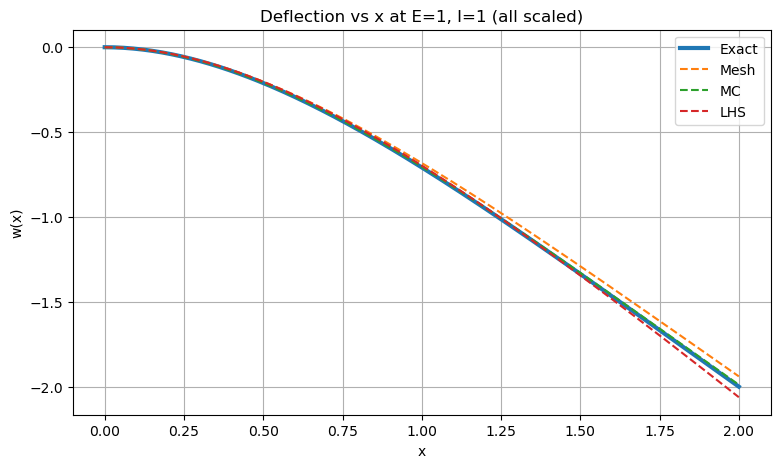


Mean/Variance under uncertainty for all models...


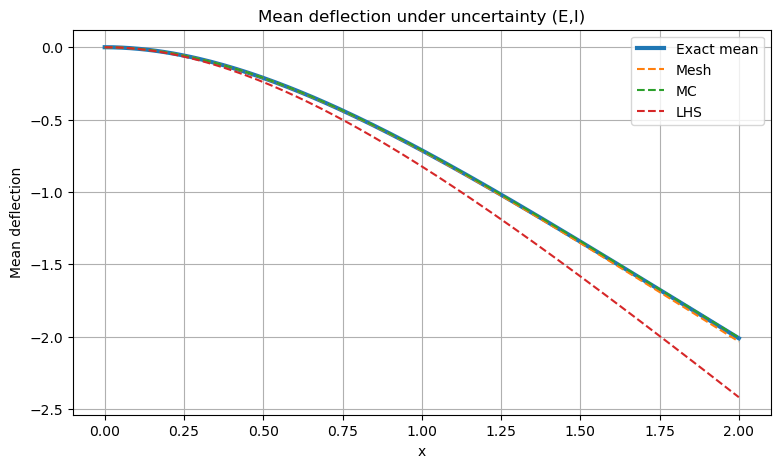

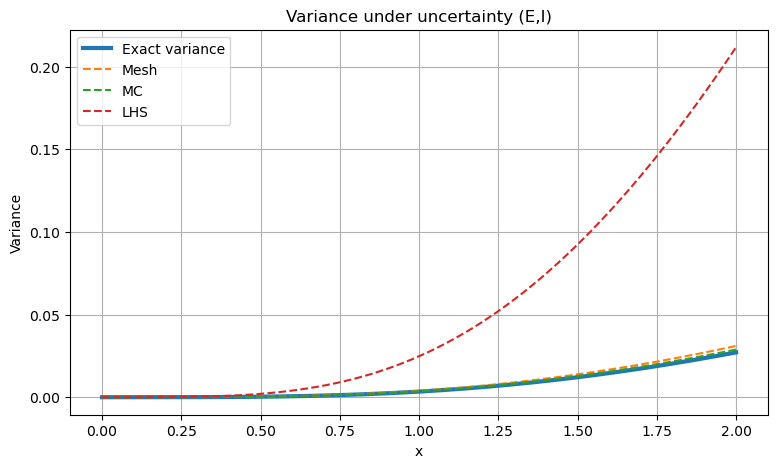


Bell curves (PDF) at x* under uncertainty...

UNCERTAINTY STATISTICS (Bell Curve)
------------------------------------------------------------
Location x* = 2.0
Exact: mean=-2.010131, std=0.165280
Mesh : mean=-2.032414, std=0.176783
MC   : mean=-2.005479, std=0.170355
LHS  : mean=-2.411407, std=0.452038
------------------------------------------------------------


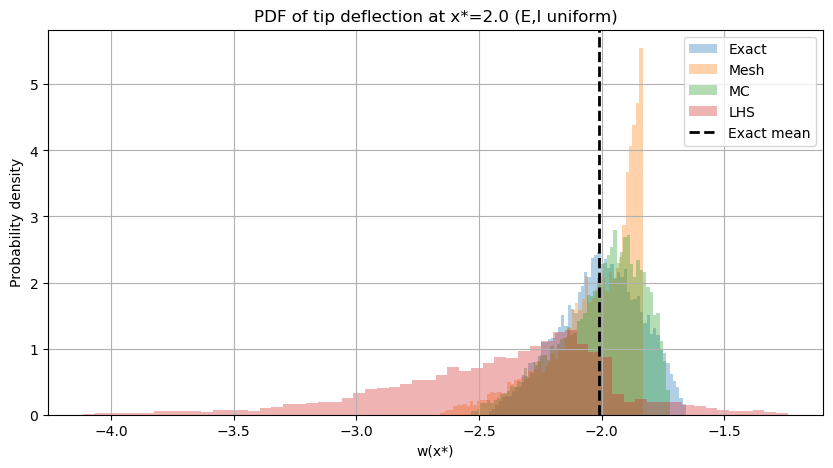

In [6]:
# Corrected=============================================================
# FULL NOTEBOOK: Mesh vs MC vs LHS (ALL SCALED) + Mean/Var + Bell Curves
# =============================================================================

import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import qmc

torch.set_default_dtype(torch.float32)

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION (physical)
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION: (xbar in [0,1], Ehat/Ihat in [-1,1])
# =============================================================================
def normalize(xei):
    xbar = xei[:, 0:1] / L
    Ehat = 2*(xei[:, 1:2] - E_range[0])/(E_range[1]-E_range[0]) - 1
    Ihat = 2*(xei[:, 2:3] - I_range[0])/(I_range[1]-I_range[0]) - 1
    return torch.cat([xbar, Ehat, Ihat], dim=1)

# =============================================================================
# DERIVATIVE wrt physical x
# =============================================================================
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:, 0:1]
    return cur

# =============================================================================
# SAMPLERS (float32 ALWAYS)
# =============================================================================
def mesh_sampler(nx=25, ne=10, ni=10):
    x = torch.linspace(0, L, nx, dtype=torch.float32)
    E = torch.linspace(E_range[0], E_range[1], ne, dtype=torch.float32)
    I = torch.linspace(I_range[0], I_range[1], ni, dtype=torch.float32)
    X, Eg, Ig = torch.meshgrid(x, E, I, indexing='ij')
    return torch.cat([X.reshape(-1,1), Eg.reshape(-1,1), Ig.reshape(-1,1)], dim=1)

def mc_sampler(n=4000):
    x = torch.rand(n,1, dtype=torch.float32) * L
    E = E_range[0] + torch.rand(n,1, dtype=torch.float32) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.rand(n,1, dtype=torch.float32) * (I_range[1]-I_range[0])
    return torch.cat([x,E,I], dim=1)

def lhs_sampler(n=12000, seed=0):
    sampler = qmc.LatinHypercube(d=3, seed=seed)
    lhs = sampler.random(n)
    lhs = np.asarray(lhs, dtype=np.float32)

    x = torch.tensor(lhs[:,0:1], dtype=torch.float32) * L
    E = E_range[0] + torch.tensor(lhs[:,1:2], dtype=torch.float32) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.tensor(lhs[:,2:3], dtype=torch.float32) * (I_range[1]-I_range[0])
    return torch.cat([x,E,I], dim=1)

def bc_sampler(n_bc=300, seed=123):
    # boundary points at x = L, with random E,I
    xei = mc_sampler(n_bc)
    xei[:,0:1] = L
    return xei

# =============================================================================
# TRAIN PIELM (SCALED FORMULATION) -- USED FOR ALL: Mesh/MC/LHS
# wbar = xbar^2 * (H beta + beta0)
# PDE: L^4 * d^4 wbar / dx^4 = 1
# BC at x=L: wbar''=0, wbar'''=0
# physical: w = (Q L^4/(E I)) * wbar
# =============================================================================
def train_pielm_scaled(
    xei, xei_bc,
    hidden_size=50,
    seed=0,
    lambda_reg=1.0,
    gauss_scale=0.5,
    bc_weight=20.0,
):
    torch.manual_seed(seed)

    W = torch.randn(3, hidden_size, dtype=torch.float32) * 0.1
    b = torch.randn(hidden_size, dtype=torch.float32) * 0.1

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # -------------------- PDE rows --------------------
    xei = xei.to(torch.float32).requires_grad_(True)

    xbar = xei[:,0:1] / L
    H = activation(normalize(xei) @ W + b)            # [N, hidden]
    Phi = (xbar**2) * H                                # [N, hidden]
    Phi_aug = torch.hstack([Phi, xbar**2])             # + beta0

    Acols = []
    for j in range(hidden_size + 1):
        w4 = derivative(Phi_aug[:, j:j+1], xei, 4)
        Acols.append((L**4) * w4)
    A_pde = torch.hstack(Acols)
    b_pde = torch.ones(A_pde.shape[0], 1, dtype=torch.float32)

    # mild scaling
    pde_scale = torch.mean(torch.abs(A_pde)).clamp_min(1e-8)
    A_pde = A_pde / pde_scale
    b_pde = b_pde / pde_scale

    # -------------------- BC rows --------------------
    xei_bc = xei_bc.to(torch.float32).requires_grad_(True)

    xbarL = xei_bc[:,0:1] / L
    HL = activation(normalize(xei_bc) @ W + b)
    PhiL = (xbarL**2) * HL
    PhiL_aug = torch.hstack([PhiL, xbarL**2])

    BC2_cols, BC3_cols = [], []
    for j in range(hidden_size + 1):
        BC2_cols.append(derivative(PhiL_aug[:, j:j+1], xei_bc, 2))
        BC3_cols.append(derivative(PhiL_aug[:, j:j+1], xei_bc, 3))

    C = torch.vstack([torch.hstack(BC2_cols), torch.hstack(BC3_cols)])
    d = torch.zeros(C.shape[0], 1, dtype=torch.float32)

    bc_scale = torch.mean(torch.abs(C)).clamp_min(1e-8)
    C = (bc_weight / bc_scale) * C
    d = (bc_weight / bc_scale) * d

    # -------------------- KKT --------------------
    A_T = A_pde.T
    C_T = C.T

    KKT = torch.vstack([
        torch.hstack([A_T @ A_pde + lambda_reg * torch.eye(hidden_size + 1), C_T]),
        torch.hstack([C, torch.zeros((C.shape[0], C.shape[0]), dtype=torch.float32)])
    ])
    rhs = torch.vstack([A_T @ b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)
    beta_aug = sol[:hidden_size+1]
    beta = beta_aug[:-1]
    beta0 = beta_aug[-1].item()

    # -------------------- predictor (physical) --------------------
    def predict(xei_query):
        xei_query = xei_query.to(torch.float32)
        x = xei_query[:,0:1]
        E = xei_query[:,1:2]
        I = xei_query[:,2:3]

        xbarq = x / L
        Hq = activation(normalize(xei_query) @ W + b)
        wbar = (xbarq**2) * (Hq @ beta + beta0)
        w_phys = (Q * L**4 / (E * I)) * wbar
        return w_phys

    return predict, beta0

# =============================================================================
# VALIDATE (relative error, max abs) on MC test points
# =============================================================================
def validate(predict, n_test=10000):
    xei = mc_sampler(n_test)
    w_pred = predict(xei)
    w_exact = analytical_solution(xei[:,0:1], xei[:,1:2], xei[:,2:3])
    rel = torch.norm(w_pred - w_exact) / torch.norm(w_exact)
    max_abs = torch.max(torch.abs(w_pred - w_exact)).item()
    return rel.item(), max_abs

# =============================================================================
# prediction time
# =============================================================================
def pred_time(predict, n_points=6000, n_repeat=30):
    xei = mc_sampler(n_points)
    predict(xei)  # warm-up
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        predict(xei)
    t1 = time.perf_counter()
    return (t1 - t0)/n_repeat

# =============================================================================
# TRAIN 3 MODELS (all scaled)
# =============================================================================
print("Training Mesh Grid...")
xei_mesh = mesh_sampler(25,10,10)
xei_bc   = bc_sampler(350)

mesh_predict, mesh_beta0 = train_pielm_scaled(
    xei_mesh, xei_bc,
    hidden_size=50, seed=0, lambda_reg=1.0, gauss_scale=0.5, bc_weight=20.0
)

print("Training Monte Carlo...")
xei_mc = mc_sampler(4000)
mc_predict, mc_beta0 = train_pielm_scaled(
    xei_mc, xei_bc,
    hidden_size=50, seed=0, lambda_reg=1.0, gauss_scale=0.5, bc_weight=20.0
)

print("Training Latin Hypercube...")
xei_lhs = lhs_sampler(12000, seed=0)
lhs_predict, lhs_beta0 = train_pielm_scaled(
    xei_lhs, xei_bc,
    hidden_size=80, seed=0, lambda_reg=2.0, gauss_scale=0.3, bc_weight=20.0
)

# =============================================================================
# COMPARISON TABLE
# =============================================================================
mesh_err, mesh_max = validate(mesh_predict)
mc_err, mc_max     = validate(mc_predict)
lhs_err, lhs_max   = validate(lhs_predict)

mesh_t = pred_time(mesh_predict)
mc_t   = pred_time(mc_predict)
lhs_t  = pred_time(lhs_predict)

print("\n" + "="*80)
print("COMPARISON (ALL SCALED): Mesh vs MC vs LHS")
print("="*80)
print(f"{'Method':<18} | {'Rel.Error (%)':>14} | {'MaxAbs':>10} | {'PredTime (s)':>14} | {'beta0':>10}")
print("-"*80)
print(f"{'Mesh Grid':<18} | {mesh_err*100:14.3f} | {mesh_max:10.4f} | {mesh_t:14.6e} | {mesh_beta0:10.4f}")
print(f"{'Monte Carlo':<18} | {mc_err*100:14.3f} | {mc_max:10.4f} | {mc_t:14.6e} | {mc_beta0:10.4f}")
print(f"{'Latin Hypercube':<18} | {lhs_err*100:14.3f} | {lhs_max:10.4f} | {lhs_t:14.6e} | {lhs_beta0:10.4f}")
print("="*80)

# =============================================================================
# PLOT: deflection vs x at E=1, I=1
# =============================================================================
x_plot = torch.linspace(0, L, 200, dtype=torch.float32).reshape(-1,1)
xei_line = torch.cat([x_plot, torch.ones_like(x_plot), torch.ones_like(x_plot)], dim=1)

w_exact_line = analytical_solution(x_plot, 1.0, 1.0).detach().numpy().flatten()
w_mesh_line  = mesh_predict(xei_line).detach().numpy().flatten()
w_mc_line    = mc_predict(xei_line).detach().numpy().flatten()
w_lhs_line   = lhs_predict(xei_line).detach().numpy().flatten()

plt.figure(figsize=(9,5))
plt.plot(x_plot.numpy().flatten(), w_exact_line, label="Exact", linewidth=3)
plt.plot(x_plot.numpy().flatten(), w_mesh_line, "--", label="Mesh")
plt.plot(x_plot.numpy().flatten(), w_mc_line, "--", label="MC")
plt.plot(x_plot.numpy().flatten(), w_lhs_line, "--", label="LHS")
plt.xlabel("x"); plt.ylabel("w(x)")
plt.title("Deflection vs x at E=1, I=1 (all scaled)")
plt.legend(); plt.grid(True)
plt.show()

# =============================================================================
# MEAN & VARIANCE vs x under uncertainty (E,I uniform)
# =============================================================================
print("\nMean/Variance under uncertainty for all models...")

n_uq = 4000
E_uq = E_range[0] + torch.rand(n_uq,1)*(E_range[1]-E_range[0])
I_uq = I_range[0] + torch.rand(n_uq,1)*(I_range[1]-I_range[0])

x_uq = torch.linspace(0, L, 150).reshape(-1,1)

def mean_var_curve(predict_fn):
    w_all = []
    for xi in x_uq:
        xcol = torch.full((n_uq,1), xi.item())
        xei = torch.cat([xcol, E_uq, I_uq], dim=1)
        w_all.append(predict_fn(xei).detach())
    w_all = torch.stack(w_all).squeeze(-1)  # [nx, n_uq]
    mean = torch.mean(w_all, dim=1).numpy()
    var  = torch.var(w_all, dim=1).numpy()
    return mean, var

# exact
w_exact_all = []
for xi in x_uq:
    xcol = torch.full((n_uq,1), xi.item())
    w_exact_all.append(analytical_solution(xcol, E_uq, I_uq))
w_exact_all = torch.stack(w_exact_all).squeeze(-1)
mean_exact = torch.mean(w_exact_all, dim=1).numpy()
var_exact  = torch.var(w_exact_all,  dim=1).numpy()

mean_mesh, var_mesh = mean_var_curve(mesh_predict)
mean_mc,   var_mc   = mean_var_curve(mc_predict)
mean_lhs,  var_lhs  = mean_var_curve(lhs_predict)

x_np = x_uq.numpy().flatten()

plt.figure(figsize=(9,5))
plt.plot(x_np, mean_exact, linewidth=3, label="Exact mean")
plt.plot(x_np, mean_mesh, "--", label="Mesh")
plt.plot(x_np, mean_mc,   "--", label="MC")
plt.plot(x_np, mean_lhs,  "--", label="LHS")
plt.xlabel("x"); plt.ylabel("Mean deflection")
plt.title("Mean deflection under uncertainty (E,I)")
plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(x_np, var_exact, linewidth=3, label="Exact variance")
plt.plot(x_np, var_mesh, "--", label="Mesh")
plt.plot(x_np, var_mc,   "--", label="MC")
plt.plot(x_np, var_lhs,  "--", label="LHS")
plt.xlabel("x"); plt.ylabel("Variance")
plt.title("Variance under uncertainty (E,I)")
plt.legend(); plt.grid(True)
plt.show()

# =============================================================================
# BELL CURVES at x* (tip)
# =============================================================================
print("\nBell curves (PDF) at x* under uncertainty...")

x_star = L
n_pdf = 12000
x_pdf = torch.full((n_pdf,1), x_star)
E_pdf = E_range[0] + torch.rand(n_pdf,1)*(E_range[1]-E_range[0])
I_pdf = I_range[0] + torch.rand(n_pdf,1)*(I_range[1]-I_range[0])
xei_pdf = torch.cat([x_pdf, E_pdf, I_pdf], dim=1)

w_exact_pdf = analytical_solution(x_pdf, E_pdf, I_pdf).detach().numpy().flatten()
w_mesh_pdf  = mesh_predict(xei_pdf).detach().numpy().flatten()
w_mc_pdf    = mc_predict(xei_pdf).detach().numpy().flatten()
w_lhs_pdf   = lhs_predict(xei_pdf).detach().numpy().flatten()

def stats(arr):
    return float(np.mean(arr)), float(np.std(arr))

me, se = stats(w_exact_pdf)
mm, sm = stats(w_mesh_pdf)
mc2, sc2 = stats(w_mc_pdf)
ml, sl = stats(w_lhs_pdf)

print("\nUNCERTAINTY STATISTICS (Bell Curve)")
print("-"*60)
print(f"Location x* = {x_star}")
print(f"Exact: mean={me:.6f}, std={se:.6f}")
print(f"Mesh : mean={mm:.6f}, std={sm:.6f}")
print(f"MC   : mean={mc2:.6f}, std={sc2:.6f}")
print(f"LHS  : mean={ml:.6f}, std={sl:.6f}")
print("-"*60)

plt.figure(figsize=(10,5))
plt.hist(w_exact_pdf, bins=60, density=True, alpha=0.35, label="Exact")
plt.hist(w_mesh_pdf,  bins=60, density=True, alpha=0.35, label="Mesh")
plt.hist(w_mc_pdf,    bins=60, density=True, alpha=0.35, label="MC")
plt.hist(w_lhs_pdf,   bins=60, density=True, alpha=0.35, label="LHS")
plt.axvline(me, color="k", linestyle="--", linewidth=2, label="Exact mean")
plt.xlabel("w(x*)")
plt.ylabel("Probability density")
plt.title(f"PDF of tip deflection at x*={x_star} (E,I uniform)")
plt.legend()
plt.grid(True)
plt.show()
